In [4]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin

# Полиномиальные моменты

Здесь вычисляются полиномиальные моменты сигнала. Для 1D функции используют интегралы
$$M_k = \int_{x_{\min}}^{x_{\max}} x^k f(x) \, dx$$
и центральные моменты через смещение по среднему.
Это даёт набор признаков на основе степенных функций.

In [63]:
class MomentumTransformer1D(BaseEstimator, TransformerMixin):
    """
    Transformer that computes polynomial moments for 1D data.

    This class calculates moments (mean, variance, etc.) of the input signal
    over a specified interval, providing a compact representation.
    """

    def __init__(self, order=2, x_bounds=(0, 1)):
        """
        Initialize the transformer.

        Parameters
        ----------
        order : int, default=2
            Maximum order of moments to compute (0 to order).
        x_bounds : tuple of float, default=(0, 1)
            Bounds of the x-axis interval (x_min, x_max).
        """
        self.order = order
        self.n_components = order + 1
        self.x_min = x_bounds[0]
        self.x_max = x_bounds[1]

    def fit(self, X, y=None):
        """
        Fit the transformer. No fitting required for moment computation.

        Parameters
        ----------
        X : array-like
            Input data (ignored).
        y : array-like, optional
            Target values (ignored).

        Returns
        -------
        self : object
            Returns the instance itself.
        """
        return self

    def _get_momentum(self, X, m_order=1, M_1=None):
        """
        Compute a single moment of the given order.

        Parameters
        ----------
        X : ndarray
            Input data of shape (batch, N).
        m_order : int
            Order of the moment (0, 1, or higher).
        M_1 : ndarray, optional
            First moment, used for central moments.

        Returns
        -------
        ndarray
            Computed moment of shape (batch,).
        """
        N = X.shape[-1]  # Number of points in one example
        _argument = np.linspace(self.x_min, self.x_max, N)
        _argument = np.expand_dims(_argument, axis=0)  # Shape: (1, N)

        if m_order == 0:
            return np.sum(X, axis=-1) * (self.x_max - self.x_min) / N  # Total integral
        elif m_order == 1:
            return np.sum(X * _argument, axis=-1) * (self.x_max - self.x_min) / N  # Mean position
        else:
            return (np.sum(X * (_argument - M_1) ** m_order, axis=-1) *
                    (self.x_max - self.x_min) / N) ** (1 / m_order)  # Central moment

    def transform(self, X, y=None):
        """
        Transform input data to moment features.

        Parameters
        ----------
        X : ndarray
            Input data of shape (batch, N).
        y : array-like, optional
            Target values (ignored).

        Returns
        -------
        ndarray
            Transformed data of shape (batch, n_components).
        """
        M_0 = self._get_momentum(X, m_order=0)  # Zero-order moment (integral)
        M_0 = np.expand_dims(M_0, axis=-1)
        if self.order == 0:
            return M_0

        M_1 = self._get_momentum(X, m_order=1)  # First-order moment (mean)
        M_1 = np.expand_dims(M_1, axis=-1)

        l_momentum_X = [M_0, M_1]

        for m_order in range(2, self.order + 1):
            M = self._get_momentum(X, m_order, M_1)  # Higher central moments
            M = np.expand_dims(M, axis=-1)
            l_momentum_X.append(M)

        momentum_X = np.concatenate(l_momentum_X, axis=-1)

        return momentum_X

    def get_pd_table(self, X=None):
        """
        Get moments as a pandas DataFrame.

        Parameters
        ----------
        X : ndarray, optional
            Input data. If None, uses previously transformed data.

        Returns
        -------
        pd.DataFrame
            DataFrame with moment columns.
        """
        X = self.transform(X)
        columns = [f"M_{i}" for i in range(self.n_components)]

        pd_table = pd.DataFrame(X, columns=columns)
        return pd_table

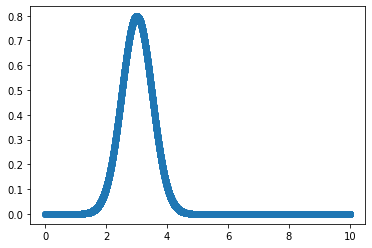

array([[0.9999    , 2.9997    , 0.49997508, 0.06082257, 0.6580206 ,
        0.19493696]])

In [64]:
x0 = 3 # 3, 8
sigma = 0.5 # 0.5

_X = np.array([np.linspace(0,10,10000)])
X = 1 / np.sqrt(2*np.pi) / sigma * np.exp(-1/2*(_X-x0)**2/sigma**2)
plt.scatter(_X, X)
plt.show()


trf = MomentumTransformer1D(order=5, x_bounds=(np.min(_X), np.max(_X)))
trf.fit_transform(X)

In [65]:
class MomentumTransformer2D(BaseEstimator, TransformerMixin):
    def __init__(self, order=2, x_order=None, y_order=None, x_bounds=(0, 1), y_bounds=(0, 1)):
        if order != None:
            if x_order == None: x_order = order
            if y_order == None: y_order = order
        else:
            order = x_order + y_order

        self.order = order
        self.x_order = x_order
        self.y_order = y_order
        self.x_bounds = x_bounds
        self.y_bounds = y_bounds

        self.x_min = x_bounds[0]
        self.x_max = x_bounds[1]
        self.y_min = y_bounds[0]
        self.y_max = y_bounds[1]

        self.order_pairs = []
        for sum_i in range(0, np.max((order, x_order, y_order))+1):
            for x_i in range(0, sum_i+1):
                y_i = sum_i - x_i
                if (x_i + y_i <= order) and (x_i <= x_order) and (y_i <= y_order):
                    self.order_pairs.append((x_i, y_i))

        self.n_components = len(self.order_pairs)


    def fit(self, X, y=None):
        return self

    def _get_momentum(self, X, m_x_order=1, m_y_order=1, M_x1_y0=None, M_x0_y1=None):
        # X.shape=[batch, N_y, N_x]
        if len(X.shape)==2:
            X = np.array(X)

        N_x = X.shape[-1] # N_x is a number of points along x-axis
        N_y = X.shape[-2] # N_y is a number of points along y-axis

        _x_argument = np.linspace(self.x_min, self.x_max, N_x)
        _x_argument = np.expand_dims(_x_argument, axis=(0,1)) # _x_argument.shape=[1, 1, N_x]
        _y_argument = np.linspace(self.y_min, self.y_max, N_y)
        _y_argument = np.expand_dims(_y_argument, axis=(0,-1)) # _y_argument.shape=[1, N_y, 1]

        d_x_d_y = (self.x_max - self.x_min) / N_x * (self.y_max - self.y_min) / N_y

        if m_x_order+m_y_order==0:
            return np.sum(X, axis=(-1,-2)) * d_x_d_y # shape=[batch]
        elif m_x_order==1 and m_y_order==0:
            return np.sum(X * _x_argument, axis=(-1,-2)) * d_x_d_y # shape=[batch]
        elif m_x_order==0 and m_y_order==1:
            return np.sum(X * _y_argument, axis=(-1,-2)) * d_x_d_y # shape=[batch]
        else:
            M_x1_y0 = np.expand_dims(M_x1_y0, axis=-1) # shape=[batch, 1, 1]
            M_x0_y1 = np.expand_dims(M_x0_y1, axis=-1) # shape=[batch, 1, 1]
            #M = (np.sum(X * (_x_argument - M_x1_y0)**m_x_order * (_y_argument - M_x0_y1)**m_y_order, axis=(-1,-2)) * d_x_d_y)**(1 / (m_x_order + m_y_order)) # shape=[batch]
            #return (np.sum(X * (_x_argument - M_x1_y0)**m_x_order * (_y_argument - M_x0_y1)**m_y_order, axis=(-1,-2)) * d_x_d_y) # shape=[batch]
            M = (np.sum(X * (_x_argument - M_x1_y0)**m_x_order * (_y_argument - M_x0_y1)**m_y_order, axis=(-1,-2)) * d_x_d_y) # shape=[batch]
            sign_M = np.sign(M)
            M = sign_M * np.abs(M)**(1 / (m_x_order + m_y_order))
            return M

    def transform(self, X, y=None):
        M_x0_y0 = self._get_momentum(X, m_x_order=0, m_y_order=0)
        M_x0_y0 = np.expand_dims(M_x0_y0, axis=-1)
        if self.order==0: return M_x0_y0

        M_x1_y0 = self._get_momentum(X, m_x_order=1, m_y_order=0)
        M_x1_y0 = np.expand_dims(M_x1_y0, axis=-1)

        M_x0_y1 = self._get_momentum(X, m_x_order=0, m_y_order=1)
        M_x0_y1 = np.expand_dims(M_x0_y1, axis=-1)

        l_momentum_X = [M_x0_y0, M_x1_y0, M_x0_y1]

        for m_x_order, m_y_order in self.order_pairs[3:]:
            M = self._get_momentum(X, m_x_order, m_y_order, M_x1_y0, M_x0_y1)
            M = np.expand_dims(M, axis=-1)
            l_momentum_X.append(M)

        momentum_X = np.concatenate(l_momentum_X, axis=-1)

        return momentum_X

    def get_pd_table(self, X=None):
        X = self.transform(X)
        columns = [f"M_x{x}_y{y}" for x, y in self.order_pairs]

        pd_table = pd.DataFrame(X, columns=columns)
        return pd_table

    def get_momenta_names(self):
        return [f"M_x{x}_y{y}" for x, y in self.order_pairs]

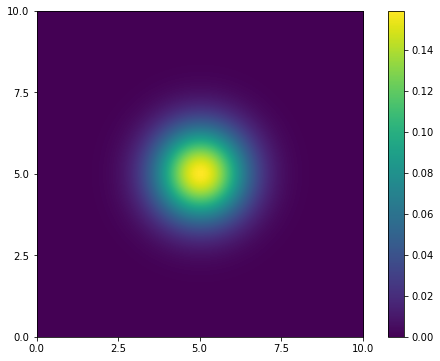

In [66]:
def gauss2D(x, y, x0 = 5, x_sigma = 1, y0 = 5, y_sigma = 1):
    gauss_x = 1 / np.sqrt(2*np.pi) / x_sigma * np.exp(-1/2*(x-x0)**2/x_sigma**2)
    gauss_y = 1 / np.sqrt(2*np.pi) / y_sigma * np.exp(-1/2*(y-y0)**2/y_sigma**2)
    
    return gauss_x*gauss_y

_x = np.linspace(0,10,1000)
_y = np.linspace(0,10,1000)
XX, YY = np.meshgrid(_x, _y)
Z = gauss2D(XX, YY, 
            x0 = 5, x_sigma = 1, # x0 = 7, x_sigma = 1, | x0 = 5, x_sigma = 1.5
            y0 = 5, y_sigma = 1) # y0 = 5, y_sigma = 1 | y0 = 5, y_sigma = 1.5


fig = plt.figure(figsize=(9, 6))
# Build the plot
plt.imshow(Z, extent=[0, 10, 0, 10], origin="lower")

# Display a color scale (values denoted by colors)
plt.colorbar()

# Limit the number of values on the axes to 4
plt.locator_params(axis='y', nbins=4)
plt.locator_params(axis='x', nbins=4)
# Set x and y limits
plt.xlim(0, 10)
plt.ylim(0, 10)
# Display the plot
plt.show()

In [94]:
len(MomentumTransformer2D(order=44).get_momenta_names())

1035

# Моменты Лежандра

Legendre-разложение проектирует сигнал на ортонормированные полиномы $P_n(x)$ на отрезке $[-1,1]$:
$$
a_n = \frac{2n+1}{2} \int_{-1}^{1} f(x) P_n(x) \, dx.
$$ 

Для 2D используется произведение базисов $P_m(x) P_n(y)$.

In [67]:
class LegendreTransformer1D(BaseEstimator, TransformerMixin):
    """
    Transformer that computes Legendre polynomial coefficients for 1D data.

    This class projects 1D signals onto Legendre polynomials on [-1, 1],
    providing orthogonal basis expansion for signal representation.
    """

    def __init__(self, order=2):
        """
        Initialize the transformer.

        Parameters
        ----------
        order : int, default=2
            Maximum degree of Legendre polynomials (0 to order).
        """
        self.order = order
        self.n_components = order + 1

    def fit(self, X, y=None):
        """
        Fit the transformer. No fitting required for Legendre transform.

        Parameters
        ----------
        X : array-like
            Input data (ignored).
        y : array-like, optional
            Target values (ignored).

        Returns
        -------
        self : object
            Returns the instance itself.
        """
        return self

    def transform(self, X, y=None):
        """
        Transform input data to Legendre coefficients.

        Parameters
        ----------
        X : ndarray
            Input data of shape (batch, N).
        y : array-like, optional
            Target values (ignored).

        Returns
        -------
        ndarray
            Legendre coefficients of shape (batch, n_components).
        """
        N = X.shape[-1]  # Number of points in one example

        # Normalize the argument to [-1, 1]
        x_norm = np.linspace(-1, 1, N)
        x_norm = np.expand_dims(x_norm, axis=0)  # Shape: (1, N)

        dx = 2 / N  # Integration step for [-1, 1]

        l_coeffs = []
        for n in range(self.order + 1):
            P_n = np.polynomial.legendre.Legendre.basis(n)  # Legendre polynomial basis
            p_vals = P_n(x_norm)  # Shape: (1, N)

            integral = np.sum(X * p_vals, axis=-1) * dx  # Inner product with basis
            a_n = (2 * n + 1) / 2 * integral  # Legendre coefficient normalization

            a_n = np.expand_dims(a_n, axis=-1)  # Shape: (batch, 1)
            l_coeffs.append(a_n)

        coeffs = np.concatenate(l_coeffs, axis=-1)  # Shape: (batch, order+1)

        return coeffs

    def get_pd_table(self, X=None):
        """
        Get coefficients as a pandas DataFrame.

        Parameters
        ----------
        X : ndarray, optional
            Input data. If None, uses previously transformed data.

        Returns
        -------
        pd.DataFrame
            DataFrame with coefficient columns.
        """
        X = self.transform(X)
        columns = [f"L_{n}" for n in range(self.n_components)]

        pd_table = pd.DataFrame(X, columns=columns)
        return pd_table

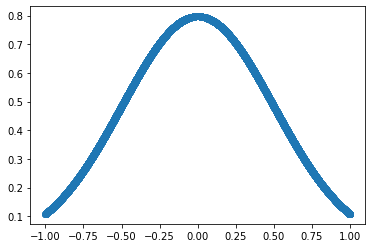

Legendre coefficients shape: (1, 16)


In [68]:
ORDER = 15

x0 = 0  # Center at 0 for [-1,1]
sigma = 0.5

_X = np.array([np.linspace(-1, 1, 10000)])  # Already in [-1,1]
X = 1 / np.sqrt(2 * np.pi) / sigma * np.exp(-1/2 * (_X - x0)**2 / sigma**2)
plt.scatter(_X, X)
plt.show()

trf = LegendreTransformer1D(order=ORDER)
coeffs = trf.fit_transform(X)
print(f"Legendre coefficients shape: {coeffs.shape}")

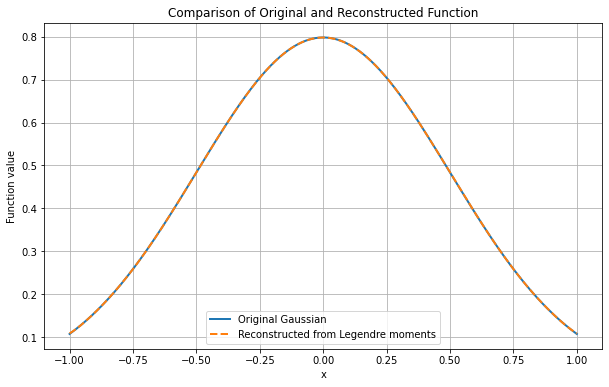

In [69]:
# Reconstruct the function from Legendre coefficients
x_norm = np.linspace(-1, 1, 10000)
reconstructed = np.zeros_like(x_norm)

for n in range(trf.order + 1):
    P_n = np.polynomial.legendre.Legendre.basis(n)
    reconstructed += coeffs[0, n] * P_n(x_norm)

# Original is already in [-1,1]
plt.figure(figsize=(10, 6))
plt.plot(_X[0], X[0], label='Original Gaussian', linewidth=2)
plt.plot(x_norm, reconstructed, label='Reconstructed from Legendre moments', linestyle='--', linewidth=2)
plt.xlabel('x')
plt.ylabel('Function value')
plt.title('Comparison of Original and Reconstructed Function')
plt.legend()
plt.grid(True)
plt.show()

In [70]:
class LegendreTransformer2D(BaseEstimator, TransformerMixin):
    def __init__(self, order=2, x_order=None, y_order=None):
        if order is not None:
            if x_order is None: x_order = order
            if y_order is None: y_order = order
        else: 
            order = x_order + y_order
        
        self.order = order
        self.x_order = x_order
        self.y_order = y_order
        
        self.order_pairs = []
        for sum_i in range(0, np.max((order, x_order, y_order)) + 1):
            for x_i in range(0, sum_i + 1):
                y_i = sum_i - x_i
                if (x_i + y_i <= order) and (x_i <= x_order) and (y_i <= y_order):
                    self.order_pairs.append((x_i, y_i))
        
        self.n_components = len(self.order_pairs)
        

    def fit(self, X, y=None):
        return self
    
    def transform(self, X, y=None):
        # X.shape=[batch, N_y, N_x]
        N_y, N_x = X.shape[-2], X.shape[-1]
        
        # Normalize arguments to [-1, 1]
        x_norm = np.linspace(-1, 1, N_x)
        x_norm = np.expand_dims(x_norm, axis=(0, 1))  # [1, 1, N_x]
        y_norm = np.linspace(-1, 1, N_y)
        y_norm = np.expand_dims(y_norm, axis=(0, -1))  # [1, N_y, 1]
        
        dx_dy = 4 / (N_x * N_y)  # Integration area element
        
        l_coeffs = []
        for m, n in self.order_pairs:
            P_m = np.polynomial.legendre.Legendre.basis(m)
            P_n = np.polynomial.legendre.Legendre.basis(n)
            
            p_m_vals = P_m(x_norm)  # [1, 1, N_x]
            p_n_vals = P_n(y_norm)  # [1, N_y, 1]
            
            integral = np.sum(X * p_m_vals * p_n_vals, axis=(-1, -2)) * dx_dy  # [batch]
            a_mn = (2 * m + 1) * (2 * n + 1) / 4 * integral  # Legendre coefficient
            
            a_mn = np.expand_dims(a_mn, axis=-1)  # [batch, 1]
            l_coeffs.append(a_mn)
        
        coeffs = np.concatenate(l_coeffs, axis=-1)  # [batch, n_components]
        
        return coeffs
    
    def get_pd_table(self, X=None):
        X = self.transform(X)
        columns = [f"L_x{x}_y{y}" for x, y in self.order_pairs]
        
        pd_table = pd.DataFrame(X, columns=columns)
        return pd_table

Order pairs: [(0, 0), (0, 1), (1, 0), (0, 2), (1, 1), (2, 0), (0, 3), (1, 2), (2, 1), (3, 0), (0, 4), (1, 3), (2, 2), (3, 1), (4, 0), (0, 5), (1, 4), (2, 3), (3, 2), (4, 1), (5, 0)]
Legendre coefficients shape: (1, 21)


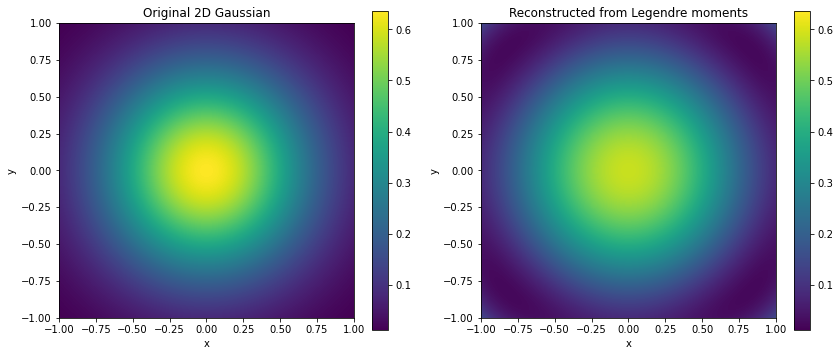

In [79]:
ORDER = 5

def gauss2D(x, y, x0=0, x_sigma=1, y0=0, y_sigma=1):
    gauss_x = 1 / np.sqrt(2*np.pi) / x_sigma * np.exp(-1/2*(x-x0)**2/x_sigma**2)
    gauss_y = 1 / np.sqrt(2*np.pi) / y_sigma * np.exp(-1/2*(y-y0)**2/y_sigma**2)
    
    return gauss_x*gauss_y

_x = np.linspace(-1, 1, 1000)
_y = np.linspace(-1, 1, 1000)
XX, YY = np.meshgrid(_x, _y)
Z = gauss2D(XX, YY, 
            x0=0, x_sigma=0.5,  # Centered at 0
            y0=0, y_sigma=0.5)

# Example with 2D Gaussian
trf = LegendreTransformer2D(order=ORDER)
print(f'Order pairs: {trf.order_pairs}')
coeffs = trf.fit_transform(np.array([Z]))
print(f'Legendre coefficients shape: {coeffs.shape}')

# Reconstruct the 2D function
N_y, N_x = Z.shape
x_norm = np.linspace(-1, 1, N_x)
y_norm = np.linspace(-1, 1, N_y)
XX_norm, YY_norm = np.meshgrid(x_norm, y_norm)

reconstructed = np.zeros_like(Z)
for i, (m, n) in enumerate(trf.order_pairs):
    P_m = np.polynomial.legendre.Legendre.basis(m)
    P_n = np.polynomial.legendre.Legendre.basis(n)
    reconstructed += coeffs[0, i] * P_m(x_norm)[None, :] * P_n(y_norm)[:, None]

# Plot original and reconstructed
vmin = min(Z.min(), reconstructed.min())
vmax = max(Z.max(), reconstructed.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(Z, extent=[-1, 1, -1, 1], origin="lower", vmin=vmin, vmax=vmax)
axes[0].set_title('Original 2D Gaussian')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

im1 = axes[1].imshow(reconstructed, extent=[-1, 1, -1, 1], origin="lower", vmin=vmin, vmax=vmax)
axes[1].set_title('Reconstructed from Legendre moments')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')

plt.colorbar(im0, ax=axes[0])
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

In [88]:
LegendreTransformer2D(order=44).get_pd_table(Z).columns.shape

(1035,)

# Гармонические моменты

Fourier-разложение использует косинусы и синусы на $[-1, 1]$:

$$
a_k = \int_{-1}^{1} f(x) \cos(k \pi x) \, dx, \qquad b_k = \int_{-1}^{1} f(x) \sin(k \pi x) \, dx.
$$

В 2D базис образован комбинациями $\cos(m\pi x)\cos(n\pi y)$, $\cos(m\pi x)\sin(n\pi y)$, $\sin(m\pi x)\cos(n\pi y)$ и $\sin(m\pi x)\sin(n\pi y)$.

In [72]:
class FourierTransformer1D(BaseEstimator, TransformerMixin):
    """
    Transformer that computes Fourier series coefficients for 1D data.

    This class expands 1D signals into Fourier series on [-1, 1],
    using cosine and sine basis functions for harmonic analysis.
    """

    def __init__(self, order=2):
        """
        Initialize the transformer.

        Parameters
        ----------
        order : int, default=2
            Maximum harmonic order (0 to order for cosines, 1 to order for sines).
        """
        self.order = order
        self.n_components = 2 * order + 1  # a0, a1..a_order, b1..b_order

    def fit(self, X, y=None):
        """
        Fit the transformer. No fitting required for Fourier transform.

        Parameters
        ----------
        X : array-like
            Input data (ignored).
        y : array-like, optional
            Target values (ignored).

        Returns
        -------
        self : object
            Returns the instance itself.
        """
        return self

    def transform(self, X, y=None):
        """
        Transform input data to Fourier coefficients.

        Parameters
        ----------
        X : ndarray
            Input data of shape (batch, N).
        y : array-like, optional
            Target values (ignored).

        Returns
        -------
        ndarray
            Fourier coefficients of shape (batch, n_components).
        """
        N = X.shape[-1]  # Number of points in one example

        # Normalize the argument to [-1, 1]
        x_norm = np.linspace(-1, 1, N)
        x_norm = np.expand_dims(x_norm, axis=0)  # Shape: (1, N)

        dx = 2 / N  # Integration step for [-1, 1]

        l_coeffs = []
        # a0 - constant term
        a0 = np.sum(X, axis=-1) * dx
        a0 = np.expand_dims(a0, axis=-1)
        l_coeffs.append(a0)

        for k in range(1, self.order + 1):
            # a_k - cosine coefficients
            a_k = np.sum(X * np.cos(k * np.pi * x_norm), axis=-1) * dx
            a_k = np.expand_dims(a_k, axis=-1)
            l_coeffs.append(a_k)

            # b_k - sine coefficients
            b_k = np.sum(X * np.sin(k * np.pi * x_norm), axis=-1) * dx
            b_k = np.expand_dims(b_k, axis=-1)
            l_coeffs.append(b_k)

        coeffs = np.concatenate(l_coeffs, axis=-1)  # Shape: (batch, 2*order+1)

        return coeffs

    def get_pd_table(self, X=None):
        """
        Get coefficients as a pandas DataFrame.

        Parameters
        ----------
        X : ndarray, optional
            Input data. If None, uses previously transformed data.

        Returns
        -------
        pd.DataFrame
            DataFrame with coefficient columns.
        """
        X = self.transform(X)
        columns = ['F_a0']
        for k in range(1, self.order + 1):
            columns.append(f'F_a{k}')
            columns.append(f'F_b{k}')

        pd_table = pd.DataFrame(X, columns=columns)
        return pd_table

In [73]:
class FourierTransformer2D(BaseEstimator, TransformerMixin):
    """
    Transformer that computes 2D Fourier series coefficients for 2D data.

    This class expands 2D images into 2D Fourier series on [-1, 1] x [-1, 1],
    using combinations of cosine and sine basis functions for harmonic analysis.
    Coefficients are conditionally included based on m and n values to avoid redundancy.
    """

    def __init__(self, order=2, x_order=None, y_order=None):
        """
        Initialize the transformer.

        Parameters
        ----------
        order : int, default=2
            Maximum total order of 2D Fourier harmonics.
        x_order : int, optional
            Maximum order in x-direction. If None, uses order.
        y_order : int, optional
            Maximum order in y-direction. If None, uses order.
        """
        if order is not None:
            if x_order is None: x_order = order
            if y_order is None: y_order = order
        else:
            order = x_order + y_order

        self.order = order
        self.x_order = x_order
        self.y_order = y_order

        self.order_pairs = []
        self.n_components = 0
        for sum_i in range(0, np.max((order, x_order, y_order)) + 1):
            for x_i in range(0, sum_i + 1):
                y_i = sum_i - x_i
                if (x_i + y_i <= order) and (x_i <= x_order) and (y_i <= y_order):
                    self.order_pairs.append((x_i, y_i))
                    self.n_components += 1
                    if y_i != 0:
                        self.n_components += 1
                    if x_i != 0:
                        self.n_components += 1
                    if x_i != 0 and y_i != 0:
                        self.n_components += 1

    def fit(self, X, y=None):
        """
        Fit the transformer. No fitting required for Fourier transform.

        Parameters
        ----------
        X : array-like
            Input data (ignored).
        y : array-like, optional
            Target values (ignored).

        Returns
        -------
        self : object
            Returns the instance itself.
        """
        return self

    def transform(self, X, y=None):
        """
        Transform input data to 2D Fourier coefficients.

        Parameters
        ----------
        X : ndarray
            Input data of shape (batch, N_y, N_x).
        y : array-like, optional
            Target values (ignored).

        Returns
        -------
        ndarray
            Fourier coefficients of shape (batch, n_components).
        """
        # X.shape=[batch, N_y, N_x]
        N_y, N_x = X.shape[-2], X.shape[-1]

        # Normalize arguments to [-1, 1]
        x_norm = np.linspace(-1, 1, N_x)
        x_norm = np.expand_dims(x_norm, axis=(0, 1))  # [1, 1, N_x]
        y_norm = np.linspace(-1, 1, N_y)
        y_norm = np.expand_dims(y_norm, axis=(0, -1))  # [1, N_y, 1]

        dx_dy = 4 / (N_x * N_y)  # Integration area element

        l_coeffs = []
        for m, n in self.order_pairs:
            a_mn = np.sum(X * np.cos(m * np.pi * x_norm) * np.cos(n * np.pi * y_norm), axis=(-1, -2)) * dx_dy
            a_mn = np.expand_dims(a_mn, axis=-1)
            l_coeffs.append(a_mn)

            if n != 0:
                b_mn = np.sum(X * np.cos(m * np.pi * x_norm) * np.sin(n * np.pi * y_norm), axis=(-1, -2)) * dx_dy
                b_mn = np.expand_dims(b_mn, axis=-1)
                l_coeffs.append(b_mn)

            if m != 0:
                c_mn = np.sum(X * np.sin(m * np.pi * x_norm) * np.cos(n * np.pi * y_norm), axis=(-1, -2)) * dx_dy
                c_mn = np.expand_dims(c_mn, axis=-1)
                l_coeffs.append(c_mn)

            if m != 0 and n != 0:
                d_mn = np.sum(X * np.sin(m * np.pi * x_norm) * np.sin(n * np.pi * y_norm), axis=(-1, -2)) * dx_dy
                d_mn = np.expand_dims(d_mn, axis=-1)
                l_coeffs.append(d_mn)

        coeffs = np.concatenate(l_coeffs, axis=-1)  # [batch, n_components]
        return coeffs

    def get_pd_table(self, X=None):
        """
        Get coefficients as a pandas DataFrame.

        Parameters
        ----------
        X : ndarray, optional
            Input data. If None, uses previously transformed data.

        Returns
        -------
        pd.DataFrame
            DataFrame with coefficient columns.
        """
        X = self.transform(X)
        columns = []
        for m, n in self.order_pairs:
            columns.append(f"F_a_{m}_{n}")
            if n != 0:
                columns.append(f"F_b_{m}_{n}")
            if m != 0:
                columns.append(f"F_c_{m}_{n}")
            if m != 0 and n != 0:
                columns.append(f"F_d_{m}_{n}")

        pd_table = pd.DataFrame(X, columns=columns)
        return pd_table

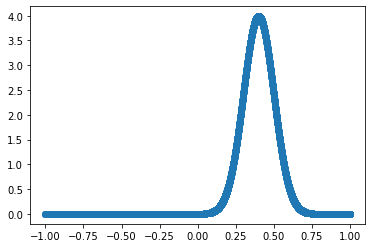

Fourier coefficients shape: (1, 101)


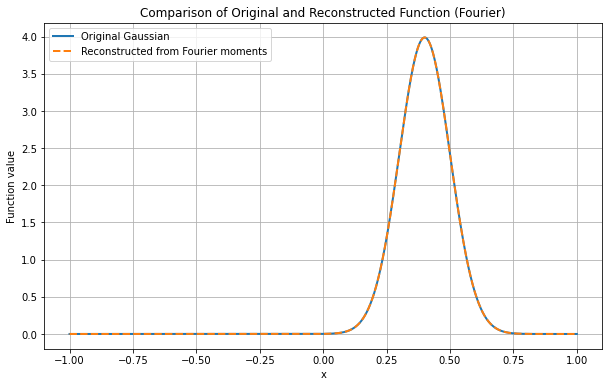

3.9890231433841987 3.989422085774646


In [74]:
# Example for FourierTransformer1D
x0 = 0.4  # Center at 0
sigma = 0.1

ORDER = 50

_X = np.array([np.linspace(-1, 1, 10000)])
X = 1 / np.sqrt(2 * np.pi) / sigma * np.exp(-1/2 * (_X - x0)**2 / sigma**2)
plt.scatter(_X, X)
plt.show()

trf = FourierTransformer1D(order=ORDER)
coeffs = trf.fit_transform(X)
print(f"Fourier coefficients shape: {coeffs.shape}")

# Reconstruct the function from Fourier coefficients
x_norm = np.linspace(-1, 1, 10000)
reconstructed = np.zeros_like(x_norm)

# a0 / 2
reconstructed += coeffs[0, 0] / 2

for k in range(1, trf.order + 1):
    a_k = coeffs[0, 2*k - 1]  # a1, a2, ... at indices 1,3,5,...
    b_k = coeffs[0, 2*k]      # b1, b2, ... at indices 2,4,6,...
    reconstructed += a_k * np.cos(k * np.pi * x_norm) + b_k * np.sin(k * np.pi * x_norm)

plt.figure(figsize=(10, 6))
plt.plot(_X[0], X[0], label='Original Gaussian', linewidth=2)
plt.plot(x_norm, reconstructed, label='Reconstructed from Fourier moments', linestyle='--', linewidth=2)
plt.xlabel('x')
plt.ylabel('Function value')
plt.title('Comparison of Original and Reconstructed Function (Fourier)')
plt.legend()
plt.grid(True)
plt.show()

print(max(reconstructed), np.max(X))


Order pairs: 66
Fourier coefficients shape: (1, 221)
Max reconstructed: 3.1713192591666575, Max original: 3.1829330134783156


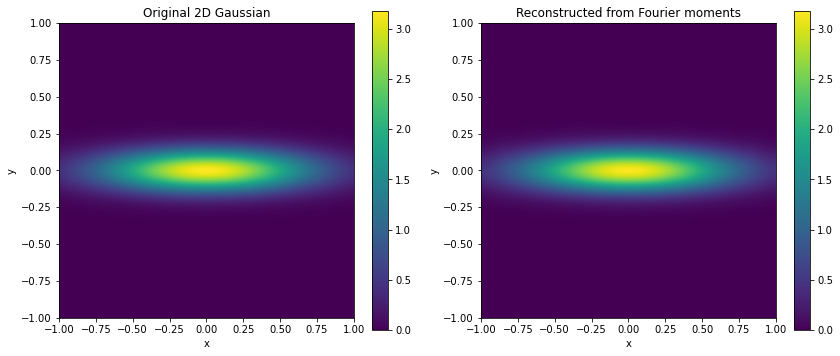

In [75]:
ORDER = 10

def gauss2D(x, y, x0=0, x_sigma=1, y0=0, y_sigma=1):
    gauss_x = 1 / np.sqrt(2*np.pi) / x_sigma * np.exp(-1/2*(x-x0)**2/x_sigma**2)
    gauss_y = 1 / np.sqrt(2*np.pi) / y_sigma * np.exp(-1/2*(y-y0)**2/y_sigma**2)
    
    return gauss_x*gauss_y

_x = np.linspace(-1, 1, 1000)
_y = np.linspace(-1, 1, 1000)
XX, YY = np.meshgrid(_x, _y)
Z = gauss2D(XX, YY, 
            x0=0, x_sigma=0.5,  # Centered at 0
            y0=0, y_sigma=0.1)

# Example for FourierTransformer2D
trf = FourierTransformer2D(order=ORDER)
print(f'Order pairs: {len(trf.order_pairs)}')
coeffs = trf.fit_transform(np.array([Z]))
print(f'Fourier coefficients shape: {coeffs.shape}')

# Reconstruct the 2D function
N_y, N_x = Z.shape
x_norm = np.linspace(-1, 1, N_x)
y_norm = np.linspace(-1, 1, N_y)
XX_norm, YY_norm = np.meshgrid(x_norm, y_norm)

reconstructed = np.zeros_like(Z)
idx = 0
for m, n in trf.order_pairs:
    a_mn = coeffs[0, idx]
    idx += 1

    cos_mx = np.cos(m * np.pi * x_norm)[None, :]
    sin_mx = np.sin(m * np.pi * x_norm)[None, :]
    cos_ny = np.cos(n * np.pi * y_norm)[:, None]
    sin_ny = np.sin(n * np.pi * y_norm)[:, None]

    if m == 0 and n == 0:
        reconstructed += a_mn / 4
    elif m == 0 or n == 0:
        reconstructed += 0.5 * a_mn * cos_mx * cos_ny
    else:
        reconstructed += a_mn * cos_mx * cos_ny

    if n != 0:
        b_mn = coeffs[0, idx]
        idx += 1
        if m == 0:
            reconstructed += 0.5 * b_mn * sin_ny
        else:
            reconstructed += b_mn * cos_mx * sin_ny

    if m != 0:
        c_mn = coeffs[0, idx]
        idx += 1
        if n == 0:
            reconstructed += 0.5 * c_mn * sin_mx
        else:
            reconstructed += c_mn * sin_mx * cos_ny

    if m != 0 and n != 0:
        d_mn = coeffs[0, idx]
        idx += 1
        reconstructed += d_mn * sin_mx * sin_ny

print(f'Max reconstructed: {np.max(reconstructed)}, Max original: {np.max(Z)}')

# Plot original and reconstructed
vmin = min(Z.min(), reconstructed.min())
vmax = max(Z.max(), reconstructed.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(Z, extent=[-1, 1, -1, 1], origin="lower", vmin=vmin, vmax=vmax)
axes[0].set_title('Original 2D Gaussian')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

im1 = axes[1].imshow(reconstructed, extent=[-1, 1, -1, 1], origin="lower", vmin=vmin, vmax=vmax)
axes[1].set_title('Reconstructed from Fourier moments')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')

plt.colorbar(im0, ax=axes[0])
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()


In [125]:
FourierTransformer2D(order=7).get_pd_table(Z).columns.shape

(113,)

# Полиномы Цернике

Zernike-разложение строится на единичном круге $r\le 1$:
$$Z_n^m(r,\theta) = R_n^{|m|}(r) \cos(m \theta) \quad (m\ge 0),$$
$$Z_n^m(r,\theta) = R_n^{|m|}(r) \sin(|m| \theta) \quad (m<0),$$
где
$$R_n^m(r)=\sum_{k=0}^{\frac{n-|m|}{2}} (-1)^k \frac{(n-k)!}{k!\left(\frac{n+|m|}{2}-k\right)!\left(\frac{n-|m|}{2}-k\right)!} r^{n-2k}. $$
Коэффициенты вычисляются как
$$A_{nm} = \frac{n+1}{\pi} \int_{0}^{2\pi}\int_{0}^{1} f(r,\theta) Z_n^m(r,\theta) r\,dr\,d\theta.$$
(вычисление интегралов производится в прямоугольной СК)

In [5]:
class ZernikeTransformer2D(BaseEstimator, TransformerMixin):
    """
    Transformer that computes Zernike polynomial coefficients for 2D data.

    This class projects 2D images onto Zernike polynomials on a circle,
    providing orthogonal basis expansion for optical wavefront analysis.
    """

    def __init__(self, order=2, x_bounds=(0, 1), y_bounds=(0, 1), center=None, radius_mode='min'):
        """
        Initialize the transformer.

        Parameters
        ----------
        order : int, default=2
            Maximum radial order of Zernike polynomials.
        x_bounds : tuple of float, default=(0, 1)
            Bounds of the x-axis.
        y_bounds : tuple of float, default=(0, 1)
            Bounds of the y-axis.
        center : tuple of float, optional
            Center coordinates (x0, y0). If None, computed as centroid.
        radius_mode : str, default='min'
            'min' for minimum distance to boundary, 'max' for maximum to corner.
        """
        self.order = order
        self.x_bounds = x_bounds
        self.y_bounds = y_bounds
        self.center = center
        self.radius_mode = radius_mode

        # Zernike modes: list of (n, m) pairs
        self.modes = []
        for n in range(order + 1):
            for m in range(-n, n + 1, 2):  # m from -n to n, step 2
                self.modes.append((n, m))
        self.n_components = len(self.modes)

    def _radial_poly(self, n, m, r):
        """
        Compute radial Zernike polynomial R_n^m(r).
        """
        if n == 0:
            return np.ones_like(r)
        R = np.zeros_like(r)
        for k in range((n - abs(m)) // 2 + 1):
            binom1 = math.factorial(n - k)
            binom2 = math.factorial(k)
            binom3 = math.factorial((n + abs(m)) // 2 - k)
            binom4 = math.factorial((n - abs(m)) // 2 - k)
            R += ((-1) ** k * binom1 / (binom2 * binom3 * binom4)) * r ** (n - 2 * k)
        return R

    def _zernike_poly(self, n, m, x, y, x0, y0, R):
        """
        Compute Zernike polynomial Z_n^m at points (x, y).
        """
        r = np.sqrt((x - x0)**2 + (y - y0)**2) / R
        theta = np.arctan2(y - y0, x - x0)
        mask = r <= 1  # Only inside circle
        Z = np.zeros_like(r)
        if abs(m) <= n:
            R_nm = self._radial_poly(n, abs(m), r)
            if m >= 0:
                Z[mask] = R_nm[mask] * np.cos(m * theta[mask])
            else:
                Z[mask] = R_nm[mask] * np.sin(abs(m) * theta[mask])
        return Z

    def fit(self, X, y=None):
        """
        Fit the transformer.

        No internal parameters are learned in advance for Zernike expansion.

        Parameters
        ----------
        X : array-like
            Input data (ignored).
        y : array-like, optional
            Target values (ignored).

        Returns
        -------
        self : object
            Returns the instance itself.
        """
        return self

    def transform(self, X, y=None):
        """
        Transform input data to Zernike coefficients.

        The center of mass is computed for each sample when `center` is None.
        The radius is then derived from the chosen radius mode.

        Parameters
        ----------
        X : ndarray
            Input data of shape (batch, N_y, N_x).
        y : array-like, optional
            Target values (ignored).

        Returns
        -------
        ndarray
            Zernike coefficients of shape (batch, n_components).
        """
        if len(X.shape)==2:
             X = X[None, :, :]
        batch, N_y, N_x = X.shape

        # Physical grid in x and y
        x = np.linspace(self.x_bounds[0], self.x_bounds[1], N_x)
        y = np.linspace(self.y_bounds[0], self.y_bounds[1], N_y)
        XX, YY = np.meshgrid(x, y)

        dx = x[1] - x[0]
        dy = y[1] - y[0]
        dx_dy = dx * dy

        if self.center is None:
            x_coords = x[None, None, :]
            y_coords = y[None, :, None]
            total = np.sum(X, axis=(-1, -2))
            x0 = np.sum(X * x_coords, axis=(-1, -2)) / np.where(total == 0, 1, total)
            y0 = np.sum(X * y_coords, axis=(-1, -2)) / np.where(total == 0, 1, total)
            x0 = np.where(total == 0,
                          (self.x_bounds[0] + self.x_bounds[1]) / 2,
                          x0)
            y0 = np.where(total == 0,
                          (self.y_bounds[0] + self.y_bounds[1]) / 2,
                          y0)
            centers = np.stack([x0, y0], axis=-1)
        else:
            x0, y0 = self.center
            centers = np.tile(np.array([x0, y0], dtype=float)[None, :], (batch, 1))

        # Determine radius for each sample.
        # For the inscribed unit circle, the limiting radius is the nearest boundary side.
        x_min, x_max = self.x_bounds
        y_min, y_max = self.y_bounds
        side_distances = np.stack([
            centers[:, 0] - x_min,
            x_max - centers[:, 0],
            centers[:, 1] - y_min,
            y_max - centers[:, 1]
        ], axis=-1)

        if self.radius_mode == 'min':
            radii = np.min(side_distances, axis=-1)
        else:
            corners = np.array([[x_min, y_min], [x_min, y_max], [x_max, y_min], [x_max, y_max]])
            distances = np.sqrt(((centers[:, None, :] - corners[None, :, :]) ** 2).sum(axis=-1))
            radii = np.max(distances, axis=1)

        self.last_centers = centers
        self.last_radii = radii

        coeffs = np.zeros((batch, self.n_components), dtype=float)
        for i in range(batch):
            sample = X[i]
            x0_i, y0_i = centers[i]
            R_i = radii[i]
            for j, (n, m) in enumerate(self.modes):
                Z_nm = self._zernike_poly(n, m, XX, YY, x0_i, y0_i, R_i)
                coeffs[i, j] = ((n + 1) / np.pi) * np.sum(sample * Z_nm) * dx_dy / R_i**2

        return coeffs

    def get_pd_table(self, X=None):
        """
        Get coefficients as a pandas DataFrame.

        Parameters
        ----------
        X : ndarray, optional
            Input data. If None, uses previously transformed data.

        Returns
        -------
        pd.DataFrame
            DataFrame with coefficient columns.
        """
        X = self.transform(X)
        columns = [f"Z_{n}_{m}" for n, m in self.modes]

        pd_table = pd.DataFrame(X, columns=columns)
        return pd_table

Zernike modes: [(0, 0), (1, -1), (1, 1), (2, -2), (2, 0), (2, 2), (3, -3), (3, -1), (3, 1), (3, 3), (4, -4), (4, -2), (4, 0), (4, 2), (4, 4), (5, -5), (5, -3), (5, -1), (5, 1), (5, 3), (5, 5), (6, -6), (6, -4), (6, -2), (6, 0), (6, 2), (6, 4), (6, 6), (7, -7), (7, -5), (7, -3), (7, -1), (7, 1), (7, 3), (7, 5), (7, 7), (8, -8), (8, -6), (8, -4), (8, -2), (8, 0), (8, 2), (8, 4), (8, 6), (8, 8), (9, -9), (9, -7), (9, -5), (9, -3), (9, -1), (9, 1), (9, 3), (9, 5), (9, 7), (9, 9), (10, -10), (10, -8), (10, -6), (10, -4), (10, -2), (10, 0), (10, 2), (10, 4), (10, 6), (10, 8), (10, 10), (11, -11), (11, -9), (11, -7), (11, -5), (11, -3), (11, -1), (11, 1), (11, 3), (11, 5), (11, 7), (11, 9), (11, 11), (12, -12), (12, -10), (12, -8), (12, -6), (12, -4), (12, -2), (12, 0), (12, 2), (12, 4), (12, 6), (12, 8), (12, 10), (12, 12), (13, -13), (13, -11), (13, -9), (13, -7), (13, -5), (13, -3), (13, -1), (13, 1), (13, 3), (13, 5), (13, 7), (13, 9), (13, 11), (13, 13), (14, -14), (14, -12), (14, -10), 

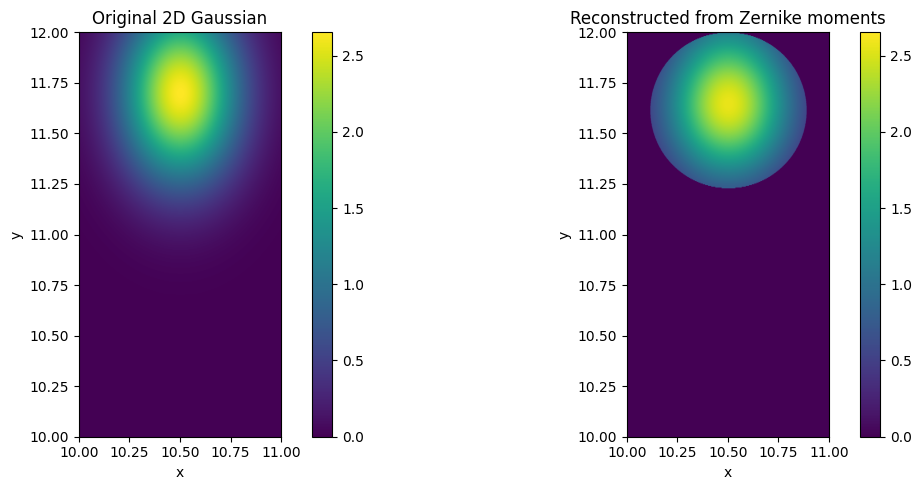

Max reconstructed: 2.5693657449050806, Max original: 2.652568752527198


In [9]:
# Parameters for Zernike example
ORDER = 15
X0 = 10.5
Y0 = 11.7
X_SIGMA = 0.2
Y_SIGMA = 0.3
GRID_SIZE = 500
X_BOUNDS = (10, 11)
Y_BOUNDS = (10, 12)
CENTER = None
RADIUS_MODE = "min"
FIG_SIZE = (12, 5)

def gauss2D(x, y, x0=0.5, x_sigma=0.2, y0=0.5, y_sigma=0.2):
    gauss_x = 1 / np.sqrt(2*np.pi) / x_sigma * np.exp(-1/2*(x-x0)**2/x_sigma**2)
    gauss_y = 1 / np.sqrt(2*np.pi) / y_sigma * np.exp(-1/2*(y-y0)**2/y_sigma**2)
    return gauss_x * gauss_y

x = np.linspace(X_BOUNDS[0], X_BOUNDS[1], 1000)
y = np.linspace(Y_BOUNDS[0], Y_BOUNDS[1], GRID_SIZE)
XX, YY = np.meshgrid(x, y)
Z = gauss2D(XX, YY, x0=X0, x_sigma=X_SIGMA, y0=Y0, y_sigma=Y_SIGMA)

trf = ZernikeTransformer2D(order=ORDER, x_bounds=X_BOUNDS, y_bounds=Y_BOUNDS, center=CENTER, radius_mode=RADIUS_MODE)
trf.fit(np.array([Z]))
print(f"Zernike modes: {trf.modes}")
coeffs = trf.transform(np.array([Z]))
print(f"Zernike coefficients shape: {coeffs.shape}")
print(f"Center used: {trf.last_centers[0]}, radius used: {trf.last_radii[0]:.4f}")

N_y, N_x = Z.shape
XX, YY = np.meshgrid(x, y)
reconstructed = np.zeros_like(Z)
center_x, center_y = trf.last_centers[0]
radius = trf.last_radii[0]
for i, (n, m) in enumerate(trf.modes):
    Z_nm = trf._zernike_poly(n, m, XX, YY, center_x, center_y, radius)
    reconstructed += coeffs[0, i] * Z_nm

vmin = min(Z.min(), reconstructed.min())
vmax = max(Z.max(), reconstructed.max())

fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)

im0 = axes[0].imshow(Z, extent=[X_BOUNDS[0], X_BOUNDS[1], Y_BOUNDS[0], Y_BOUNDS[1]], origin="lower", vmin=vmin, vmax=vmax)
axes[0].set_title("Original 2D Gaussian")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

im1 = axes[1].imshow(reconstructed, extent=[X_BOUNDS[0], X_BOUNDS[1], Y_BOUNDS[0], Y_BOUNDS[1]], origin="lower", vmin=vmin, vmax=vmax)
axes[1].set_title("Reconstructed from Zernike moments")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

plt.colorbar(im0, ax=axes[0])
plt.colorbar(im1, ax=axes[1])
plt.tight_layout()
plt.show()
print(f"Max reconstructed: {np.max(reconstructed)}, Max original: {np.max(Z)}")

In [10]:
ZernikeTransformer2D(order=13).get_pd_table(np.array([Z])).columns.shape

(105,)

In [11]:
Z.shape, Z

((500, 1000),
 array([[1.24067904e-08, 1.25628484e-08, 1.27205508e-08, ...,
         1.27205508e-08, 1.25628484e-08, 1.24067904e-08],
        [1.33813461e-08, 1.35496626e-08, 1.37197525e-08, ...,
         1.37197525e-08, 1.35496626e-08, 1.33813461e-08],
        [1.44298776e-08, 1.46113829e-08, 1.47948007e-08, ...,
         1.47948007e-08, 1.46113829e-08, 1.44298776e-08],
        ...,
        [7.25772894e-02, 7.34901984e-02, 7.44127263e-02, ...,
         7.44127263e-02, 7.34901984e-02, 7.25772894e-02],
        [7.16332776e-02, 7.25343124e-02, 7.34448410e-02, ...,
         7.34448410e-02, 7.25343124e-02, 7.16332776e-02],
        [7.06889262e-02, 7.15780825e-02, 7.24766075e-02, ...,
         7.24766075e-02, 7.15780825e-02, 7.06889262e-02]],
       shape=(500, 1000)))